**Кравчук В.О. ИУ5-64Б РК1 Вариант 11**

**Задача 2**

Номер набора данных, указанного в задаче - 3

Дополнительные требования:
    ИУ5-64Б - для произвольной колонки данных построить график "Скрипичная диаграмма (violin plot)".

Задача:
    Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему? #

1. Загружаю данные и искуственно создаю пропуски

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('toy_dataset.csv')

# Создам 'Income' (количественный) и 'City' (категориальный)
np.random.seed(42)
df.loc[df.sample(frac=0.1).index, 'Income'] = np.nan
df.loc[df.sample(frac=0.1).index, 'City'] = np.nan

print(f"Пропусков в Income: {df['Income'].isnull().sum()}")
print(f"Пропусков в City: {df['City'].isnull().sum()}")
df.head()

Пропусков в Income: 15000
Пропусков в City: 15000


,Number,City,Gender,Age,Income,Illness
0,1,NaN,Male,41,NaN,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No


2. Обработка пропусков

In [2]:
# Обработка количественного признака (Income) - Заполнение медианой
income_median = df["Income"].median()
df["Income"] = df["Income"].fillna(income_median)

# Обработка категориального признака (City) - Заполнение модой
city_mode = df["City"].mode()[0]
df["City"] = df["City"].fillna(city_mode)

print("Пропуски после обработки:")
print(df[["Income", "City"]].isnull().sum())

Пропуски после обработки:
Income    0
City      0
dtype: int64


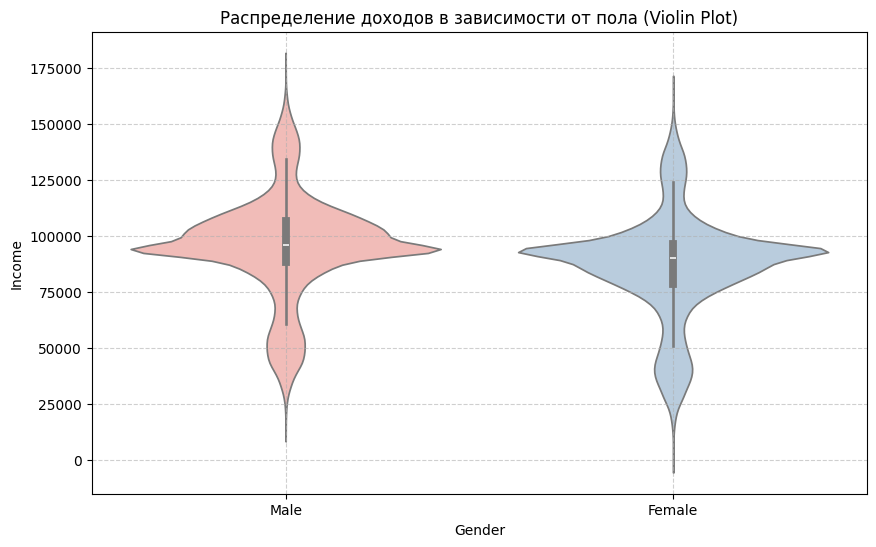

In [5]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Gender", y="Income", data=df, palette="Pastel1", hue="Gender", legend=False)
plt.title("Распределение доходов в зависимости от пола (Violin Plot)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Ответы на вопросы:**
1. Какие способы обработки пропусков использовались?
    Для количественного (Income): Заполнение медианой. (Медиана устойчива к очень высоким или низким зарплатам в выборке)
    Для категориального (City): Заполнение наиболее часто встречающимся значением (модой). (Это позволяет сохранить структуру данных, не создавая новые сущности, если количество пропусков не сильно большое.)
2. Какие признаки использовать для обучения моделей и почему?
    Для построения модели (например, предсказания болезни Illness или уровня дохода Income) я бы рекомендовал использовать:

    City(Город): Локация часто коррелирует с уровнем дохода и качеством жизни.

    Gender(Пол): Биологический фактор, важный для медицинских и демографических моделей.

    Age(Возраст): Ключевой фактор для медицинских показателей.

    Income(Зарплата): Финансовое положение часто определяет доступ к ресурсам.
    